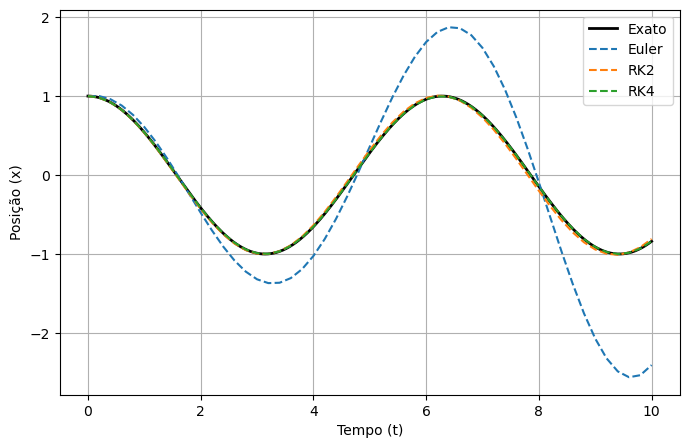

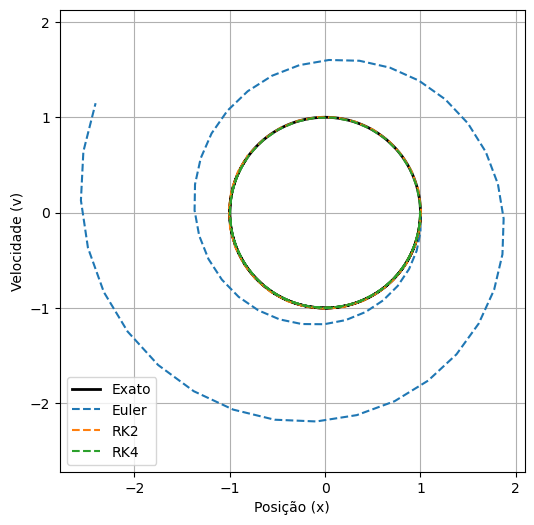

Euler: ordem de convergência (inclinação da reta) = 1.154
RK2: ordem de convergência (inclinação da reta) = 1.960
RK4: ordem de convergência (inclinação da reta) = 3.852


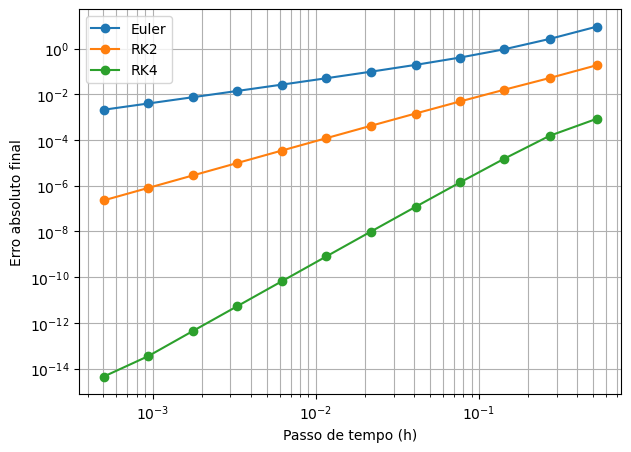

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
omega = 1.0
x0, v0 = 1.0, 0.0
T = 10.0
h = 0.2

# Equações do sistema
def deriv(t, y):
    x, v = y
    return np.array([v, -omega**2 * x])

def sol_exata(t):
    x = x0 * np.cos(omega * t) + (v0 / omega) * np.sin(omega * t)
    v = -x0 * omega * np.sin(omega * t) + v0 * np.cos(omega * t)
    return x, v

# Passos dos métodos numéricos
def euler_step(t, y, h):
    return y + h * deriv(t, y)

def rk2_step(t, y, h):
    k1 = deriv(t, y)
    k2 = deriv(t + h, y + h * k1)
    return y + h * (k1 + k2) / 2

def rk4_step(t, y, h):
    k1 = deriv(t, y)
    k2 = deriv(t + h/2, y + h*k1/2)
    k3 = deriv(t + h/2, y + h*k2/2)
    k4 = deriv(t + h, y + h*k3)
    return y + h * (k1 + 2*k2 + 2*k3 + k4) / 6

# Função de integração
def integrar(metodo, y0, T, h):
    n_steps = int(T / h)
    t_vals = np.zeros(n_steps + 1)
    y_vals = np.zeros((n_steps + 1, 2))
    t_vals[0] = 0.0
    y_vals[0] = y0
    
    for i in range(n_steps):
        t_vals[i+1] = t_vals[i] + h
        y_vals[i+1] = metodo(t_vals[i], y_vals[i], h)
        
    return t_vals, y_vals

# --- SIMULAÇÃO E GRÁFICOS ---

metodos = {'Euler': euler_step, 'RK2': rk2_step, 'RK4': rk4_step}

# Trajetória Temporal
t_exact = np.linspace(0, T, 1000)
x_exact, v_exact = sol_exata(t_exact)
plt.figure(figsize=(8, 5))
plt.plot(t_exact, x_exact, 'k', label='Exato', lw=2)

for nome, func in metodos.items():
    t, y = integrar(func, [x0, v0], T, h)
    plt.plot(t, y[:, 0], '--', label=nome)

plt.xlabel('Tempo (t)')
plt.ylabel('Posição (x)')
plt.grid(True)
plt.legend()
plt.show()

# Espaço de Fase
plt.figure(figsize=(6, 6))
plt.plot(x_exact, v_exact, 'k', label='Exato', lw=2)

for nome, func in metodos.items():
    t, y = integrar(func, [x0, v0], T, h)
    plt.plot(y[:, 0], y[:, 1], '--', label=nome)

plt.xlabel('Posição (x)')
plt.ylabel('Velocidade (v)')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

# Análise de Convergência com Regressão Linear
n_passos = np.logspace(1.3, 4.3, 12, dtype=int)
dt_list = T / n_passos
log_dt = np.log10(dt_list)
plt.figure(figsize=(7, 5))
erros_dict = {}

for nome, func in metodos.items():
    erros = []
    for dt in dt_list:
        t, y = integrar(func, [x0, v0], T, dt)
        x_final_exato, _ = sol_exata(T)
        erro = abs(y[-1, 0] - x_final_exato)
        erros.append(erro)
    
    erros_dict[nome] = erros
    plt.loglog(dt_list, erros, 'o-', label=nome)
    log_erro = np.log10(erros)
    a, b = np.polyfit(log_dt, log_erro, 1)
    print(f'{nome}: ordem de convergência (inclinação da reta) = {a:.3f}')

plt.xlabel('Passo de tempo (h)')
plt.ylabel('Erro absoluto final')
plt.grid(True, which="both")
plt.legend()
plt.show()